In [9]:
import sympy as sp

x = sp.symbols('x')
f = x**4
f_prime = sp.diff(f, x)


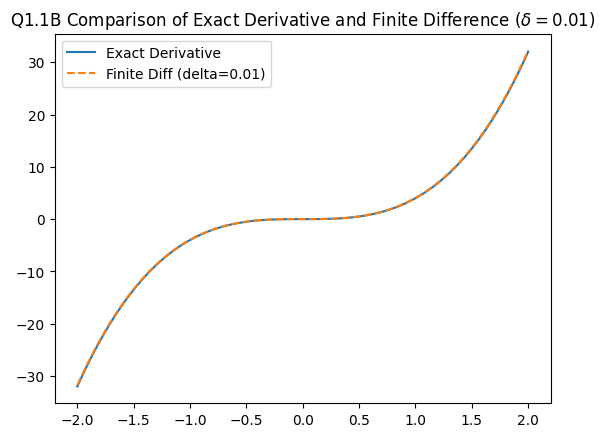

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4

def df_exact(x):
    return 4 * x**3

def forward_difference(x, delta):
    return (f(x + delta) - f(x)) / delta

x_vals = np.linspace(-2, 2, 100)
y_exact = df_exact(x_vals)
y_approx = forward_difference(x_vals, 0.01)
plt.title(r"Q1.1B Comparison of Exact Derivative and Finite Difference ($\delta=0.01$)")
plt.plot(x_vals, y_exact, label='Exact Derivative')
plt.plot(x_vals, y_approx, '--', label='Finite Diff (delta=0.01)')
plt.legend()
plt.show()

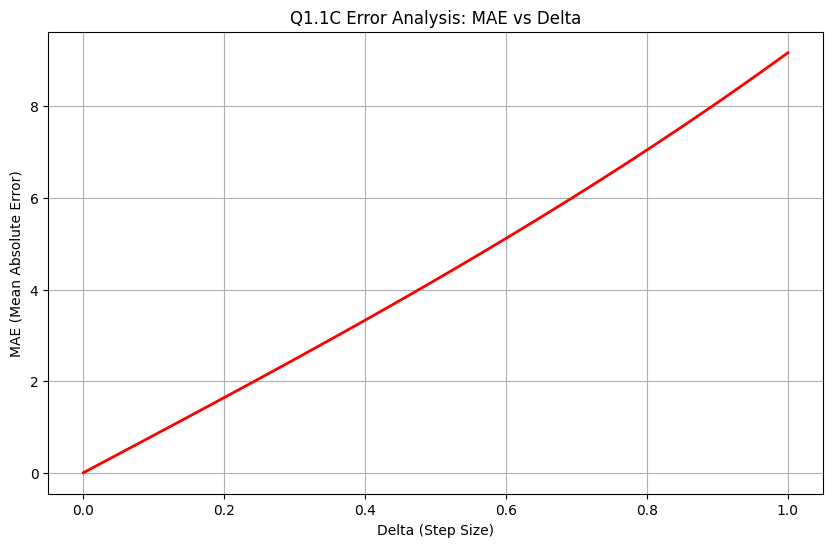

In [11]:
deltas = np.linspace(0.001, 1, 100)
mae_values = []

for d in deltas:
    approx = forward_difference(x_vals, d)
    error = np.abs(y_exact - approx)
    mae = np.mean(error)
    mae_values.append(mae)

plt.figure(figsize=(10, 6))
plt.plot(deltas, mae_values, 'r-', linewidth=2)

plt.title(r"Q1.1C Error Analysis: MAE vs Delta")
plt.xlabel('Delta (Step Size)')
plt.ylabel('MAE (Mean Absolute Error)')
plt.grid(True)
plt.show()

In [20]:
def gradient_descent(x0, alpha, num_iters=20):
    x_history = [x0]
    f_history = [f(x0)]
    x_curr = x0
    
    for _ in range(num_iters):
        grad = df_exact(x_curr)
        x_next = x_curr - alpha * grad
        
        if abs(x_next) > 1e5: 
            break 
            
        x_history.append(x_next)
        f_history.append(f(x_next))
        x_curr = x_next
        
    return x_history, f_history

alphas = [0.05, 0.5, 1.2]
x0 = 1.0
results = {}

for a in alphas:
    results[a] = gradient_descent(x0, a, num_iters=30)
    
    print(f"Learning rate {a}: Final position x = {x_hist[-1]}")

Learning rate 0.05: Final position x = 1.0
Learning rate 0.5: Final position x = 1.0
Learning rate 1.2: Final position x = 1.0


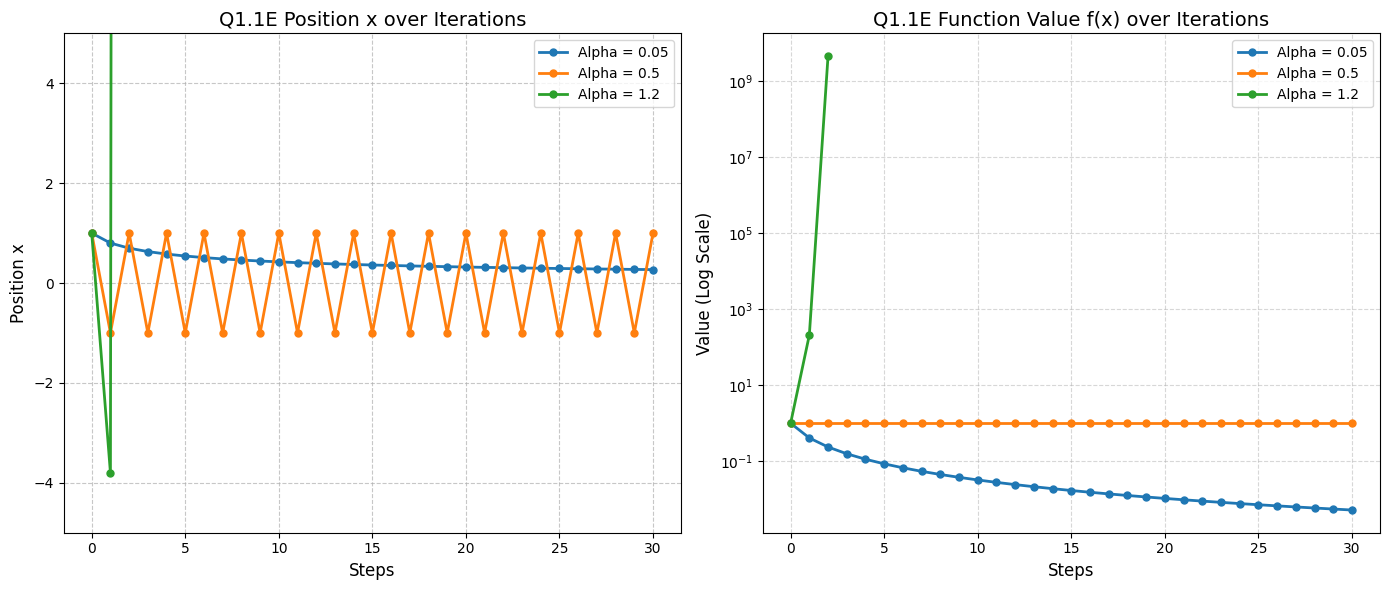

In [22]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) 
for a in alphas:
    x_hist, _ = results[a]
    plt.plot(x_hist, 'o-', label=f'Alpha = {a}', linewidth=2, markersize=5)

plt.title('Q1.1E Position x over Iterations', fontsize=14)
plt.xlabel('Steps', fontsize=12)
plt.ylabel('Position x', fontsize=12)
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-5, 5)

plt.subplot(1, 2, 2) 
for a in alphas:
    _, f_hist = results[a]
    plt.semilogy(f_hist, 'o-', label=f'Alpha = {a}', linewidth=2, markersize=5)

plt.title('Q1.1E Function Value f(x) over Iterations', fontsize=14)
plt.xlabel('Steps', fontsize=12)
plt.ylabel('Value (Log Scale)', fontsize=12)
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Q2

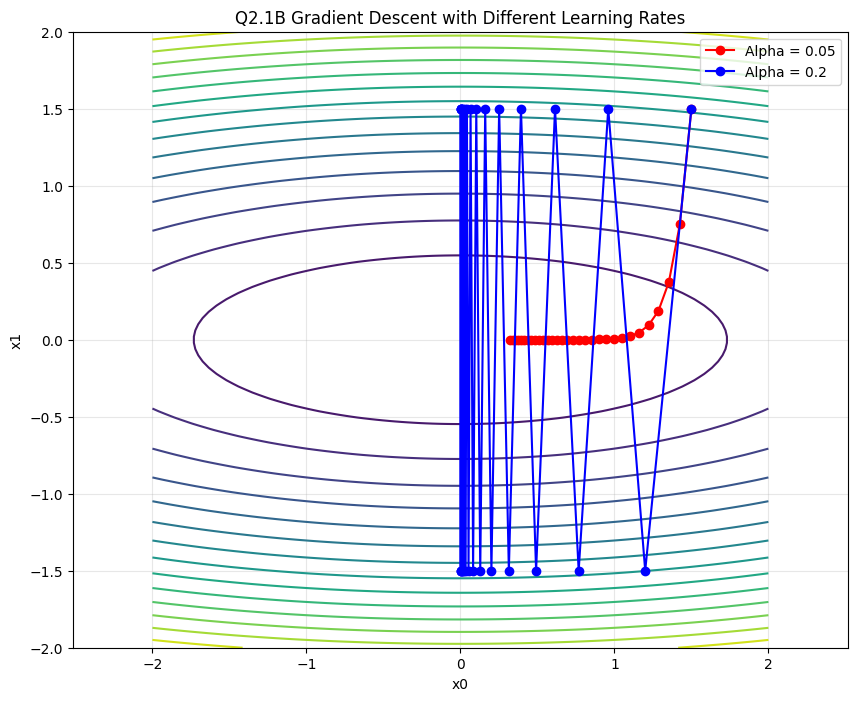

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def f_2d(x):
    return 0.5 * (x[0]**2 + 10 * x[1]**2)

def grad_2d(x):
    return np.array([x[0], 10 * x[1]])

def gd_2d(start_point, alpha, iterations=30):
    path = [start_point]
    x_curr = np.array(start_point)
    
    for _ in range(iterations):
        g = grad_2d(x_curr)
        x_next = x_curr - alpha * g
        path.append(x_next)
        x_curr = x_next
        
    return np.array(path)

plt.figure(figsize=(10, 8))
x0_range = np.linspace(-2, 2, 100)
x1_range = np.linspace(-2, 2, 100)
X0, X1 = np.meshgrid(x0_range, x1_range) 
Z = 0.5 * (X0**2 + 10 * X1**2)
plt.contour(X0, X1, Z, levels=20, cmap='viridis')

start = [1.5, 1.5] 
alphas = [0.05, 0.2] 
colors = ['red', 'blue']

for i, alpha in enumerate(alphas):
    path = gd_2d(start, alpha)
    plt.plot(path[:, 0], path[:, 1], 'o-', color=colors[i], label=f'Alpha = {alpha}')

plt.title('Q2.1B Gradient Descent with Different Learning Rates')
plt.xlabel('x0')
plt.ylabel('x1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

  Initial point x0 = -1.5: Converged to x ≈ -1.0123, f(x) ≈ -1.1006
  Initial point x0 =  1.5: Converged to x ≈ 0.9873, f(x) ≈ -0.9006


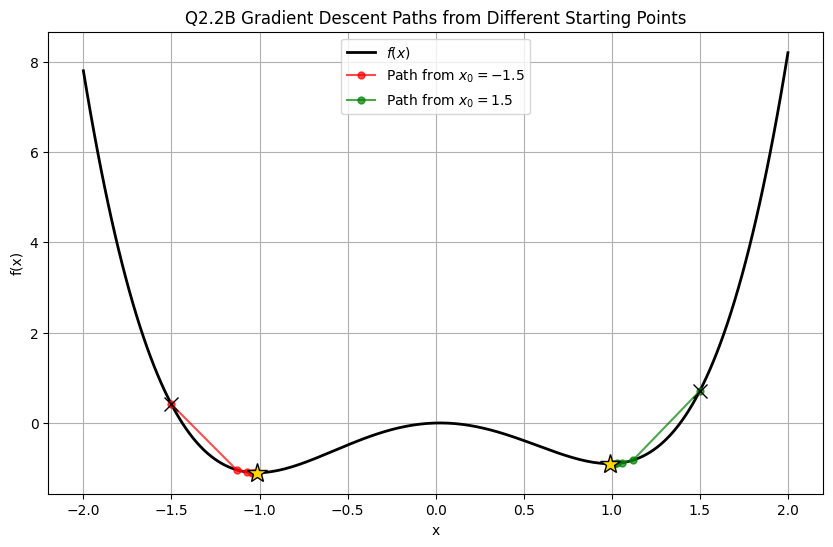

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def f_1d(x):
    return x**4 - 2 * x**2 + 0.1 * x

def grad_f_1d(x):
    return 4 * x**3 - 4 * x + 0.1

def gradient_descent_1d(x_start, alpha, num_iters=30):
    path = [x_start]
    x_curr = x_start
    
    for _ in range(num_iters):
        grad = grad_f_1d(x_curr)
        x_next = x_curr - alpha * grad
        
        path.append(x_next)
        x_curr = x_next
        
    return np.array(path)

x_vals = np.linspace(-2, 2, 200)
y_vals = f_1d(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='$f(x)$')

start_points = [-1.5, 1.5]
alpha = 0.05
colors = ['red', 'green']

for i, x0 in enumerate(start_points):
    path = gradient_descent_1d(x0, alpha)
    path_y = f_1d(path) 

    final_x = path[-1]
    final_val = f_1d(final_x)
    print(f"  Initial point x0 = {x0: >4}: Converged to x ≈ {final_x:.4f}, f(x) ≈ {final_val:.4f}")
    
    plt.plot(path, path_y, 'o-', color=colors[i], markersize=5, alpha=0.7, 
             label=f'Path from $x_0={x0}$')
    
    plt.plot(path[0], path_y[0], 'x', color='black', markersize=10) 
    plt.plot(path[-1], path_y[-1], '*', color='gold', markersize=15, markeredgecolor='black') 

plt.title('Q2.2B Gradient Descent Paths from Different Starting Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

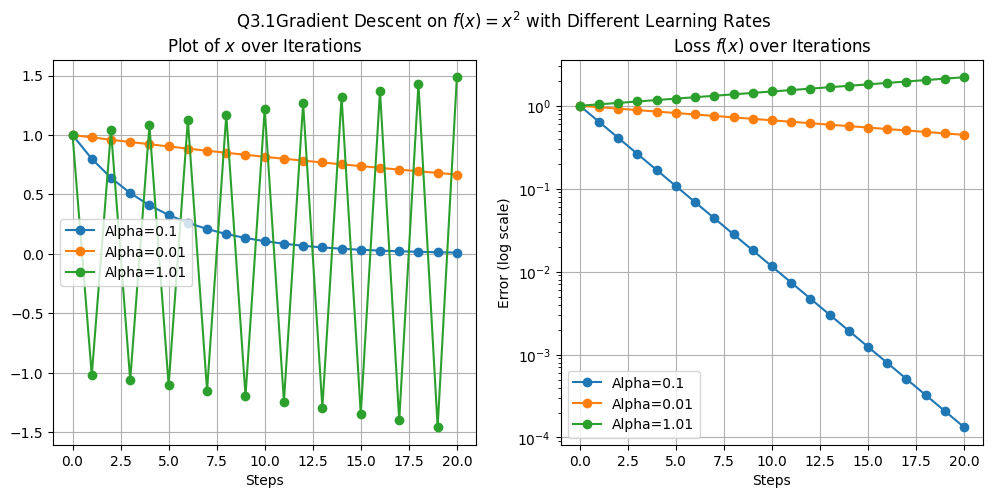

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def q3_part1():
    def f(x): return x**2
    def df(x): return 2*x
 
    alphas = [0.1, 0.01, 1.01]
    x0 = 1.0
    iterations = 20
    
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for alpha in alphas:
        x_hist = [x0]
        curr = x0
        for _ in range(iterations):
            curr = curr - alpha * df(curr)
            x_hist.append(curr)
        plt.plot(x_hist, 'o-', label=f'Alpha={alpha}')
    plt.suptitle('Q3.1Gradient Descent on $f(x)=x^2$ with Different Learning Rates')    
    plt.title('Plot of $x$ over Iterations')
    plt.xlabel('Steps')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    for alpha in alphas:
        curr = x0
        f_hist = [f(x0)]
        for _ in range(iterations):
            curr = curr - alpha * df(curr)
            f_hist.append(f(curr))

        plt.semilogy(f_hist, 'o-', label=f'Alpha={alpha}')
    
    plt.title('Loss $f(x)$ over Iterations')
    plt.xlabel('Steps')
    plt.ylabel('Error (log scale)')
    plt.grid(True)
    plt.legend()
    plt.show()

q3_part1()

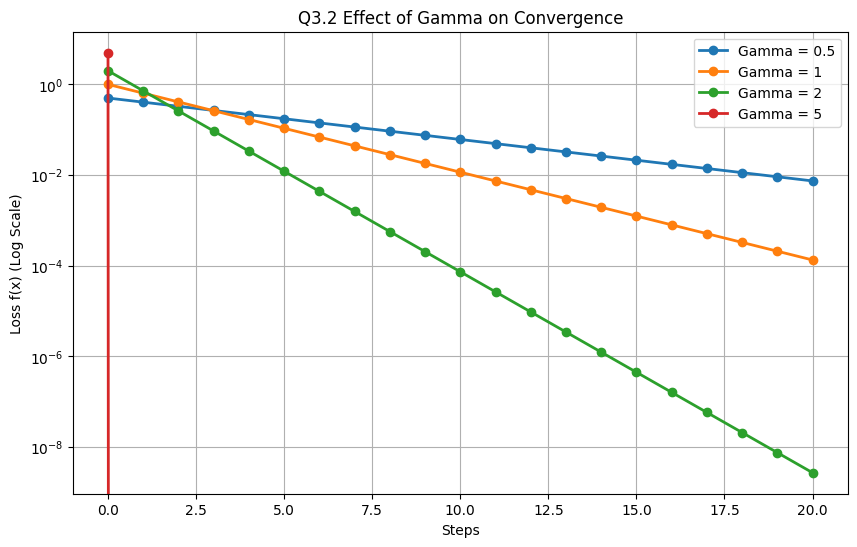

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def q3_part2():
    gammas = [0.5, 1, 2, 5]
    alpha = 0.1
    x0 = 1.0
    iterations = 20
    
    plt.figure(figsize=(10, 6))
    
    for gamma in gammas:
        f_hist = [gamma * x0**2] 
        x_curr = x0
        for _ in range(iterations):
            grad = 2 * gamma * x_curr
            x_curr = x_curr - alpha * grad
            f_hist.append(gamma * x_curr**2)

        plt.semilogy(f_hist, 'o-', label=f'Gamma = {gamma}', linewidth=2)
        
    plt.title('Q3.2 Effect of Gamma on Convergence')
    plt.xlabel('Steps')
    plt.ylabel('Loss f(x) (Log Scale)')
    plt.legend()
    plt.grid(True)
    plt.show()

q3_part2()

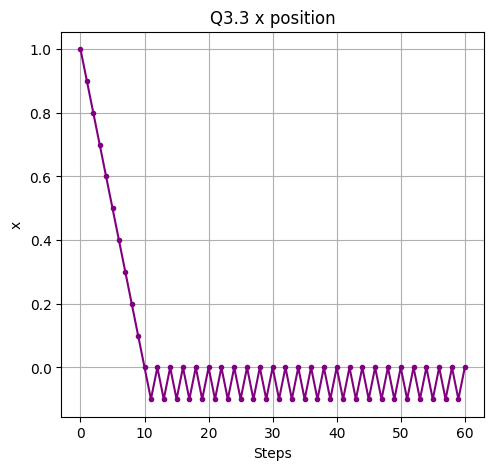

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def q3_part3():

    def f(x): return abs(x)
    
    def subgrad(x):
        if x > 0: return 1.0
        if x < 0: return -1.0
        return 0.0 
    
    x0 = 1
    alpha = 0.1
    iterations = 60
    
    x_hist = [x0]
    f_hist = [f(x0)]
    x_curr = x0
    
    for _ in range(iterations):
        g = subgrad(x_curr)
        x_curr = x_curr - alpha * g
        
        x_hist.append(x_curr)
        f_hist.append(f(x_curr))
        
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x_hist, '.-', color='purple')
    plt.title('Q3.3 x position')
    plt.xlabel('Steps')
    plt.ylabel('x')
    plt.grid(True)
    
q3_part3()

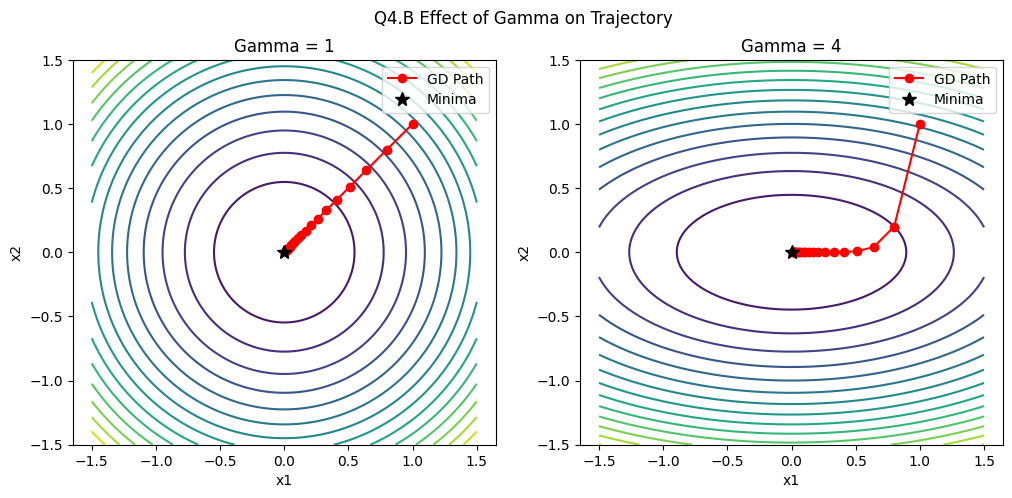

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def q4_part1():
    def gd_2d(start, gamma, alpha, steps=20):
        path = [start]
        x = np.array(start, dtype=float)
        for _ in range(steps):
            grad = np.array([2*x[0], 2*gamma*x[1]])
            x = x - alpha * grad
            path.append(x)
        return np.array(path)

    gammas = [1, 4]
    start = [1, 1]
    alpha = 0.1
    
    plt.figure(figsize=(12, 5))
    x = np.linspace(-1.5, 1.5, 100)
    y = np.linspace(-1.5, 1.5, 100)
    X, Y = np.meshgrid(x, y)
    
    for i, gamma in enumerate(gammas):
        ax = plt.subplot(1, 2, i+1)
        Z = X**2 + gamma * Y**2
        ax.contour(X, Y, Z, levels=15, cmap='viridis')
        path = gd_2d(start, gamma, alpha)
        ax.plot(path[:,0], path[:,1], 'o-', color='red', label='GD Path')
        ax.plot(0, 0, 'k*', markersize=10, label='Minima')
        
        ax.set_title(f'Gamma = {gamma}')
        ax.set_xlabel('x1'); ax.set_ylabel('x2')
        ax.axis('equal') 
        ax.legend()
        
    plt.suptitle('Q4.B Effect of Gamma on Trajectory')
    plt.show()

q4_part1()

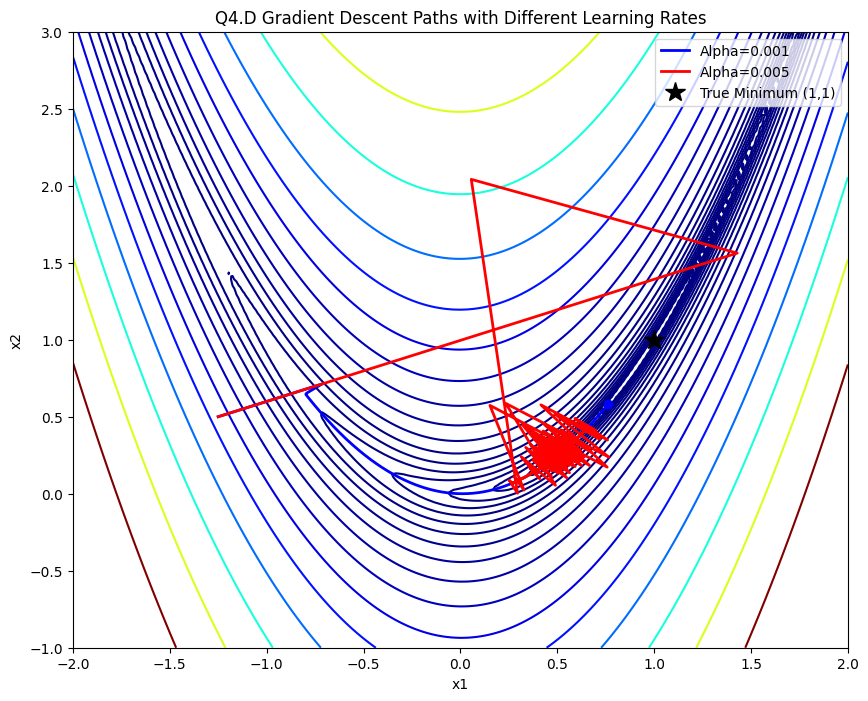

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def q4_part2():
    
    def rosen(x):
        return (1-x[0])**2 + 100 * (x[1] - x[0]**2)**2

    def grad_rosen(x):
        dx1 = -2*(1-x[0]) - 400*x[0]*(x[1] - x[0]**2)
        dx2 = 200 * (x[1] - x[0]**2)
        return np.array([dx1, dx2])

    def gd_rosen(start, alpha, steps=2000):
        path = [start]
        x = np.array(start, dtype=float)
        for _ in range(steps):
            g = grad_rosen(x)
            x = x - alpha * g
            path.append(x)
        return np.array(path)

    plt.figure(figsize=(10, 8))
    x = np.linspace(-2, 2, 200)
    y = np.linspace(-1, 3, 200)
    X, Y = np.meshgrid(x, y)
    Z = rosen([X, Y])
    plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='jet')

    start = [-1.25, 0.5]
    alphas = [0.001, 0.005]
    colors = ['blue', 'red'] 

    for i, a in enumerate(alphas):
        path = gd_rosen(start, a)
        
        plt.plot(path[:,0], path[:,1], '-', color=colors[i], label=f'Alpha={a}', linewidth=2)
        plt.plot(path[-1,0], path[-1,1], 'o', color=colors[i]) # 标记终点

    plt.plot(1, 1, 'k*', markersize=15, label='True Minimum (1,1)')
    plt.title('Q4.D Gradient Descent Paths with Different Learning Rates')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()

q4_part2()